In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data from .csv file
geopolitical_events = pd.read_csv('../data/geopolitical_events_timeline.csv')
geopolitical_events.head()

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


In [3]:
# Get datatypes of columns to check if we need to clean anything
geopolitical_events.dtypes

date                   str
event_type             str
event_description      str
event_severity       int64
dtype: object

In [4]:
# Convert data to DateTime so we can get data such as the Year, Month, and Day easily.
events_dates = pd.to_datetime(geopolitical_events['date'], format="%Y-%m-%d")
geopolitical_events['date'] = events_dates
geopolitical_events.dtypes

date                 datetime64[us]
event_type                      str
event_description               str
event_severity                int64
dtype: object

# Questions
Since the goal is to obtain a deeper understanding of oil geopolitics and how current events have been shaping it, I want to understand the following:
1. What year was the most eventful?
2. What event type is the most common?
3. What is the most common level of event severity?
4. Are events becoming more frequent now compared to before?
5. Is the event severity of different event types going up or going down?
6. Are high severity events becoming more common over time?
7. What do the most severe events have in common?

Let's begin!

## What year was the most eventful?
To answer this, we can visualize the data using a histogram to display the distribution of occurrences between different years.

In [5]:
# Get the years
years = geopolitical_events['date'].dt.year

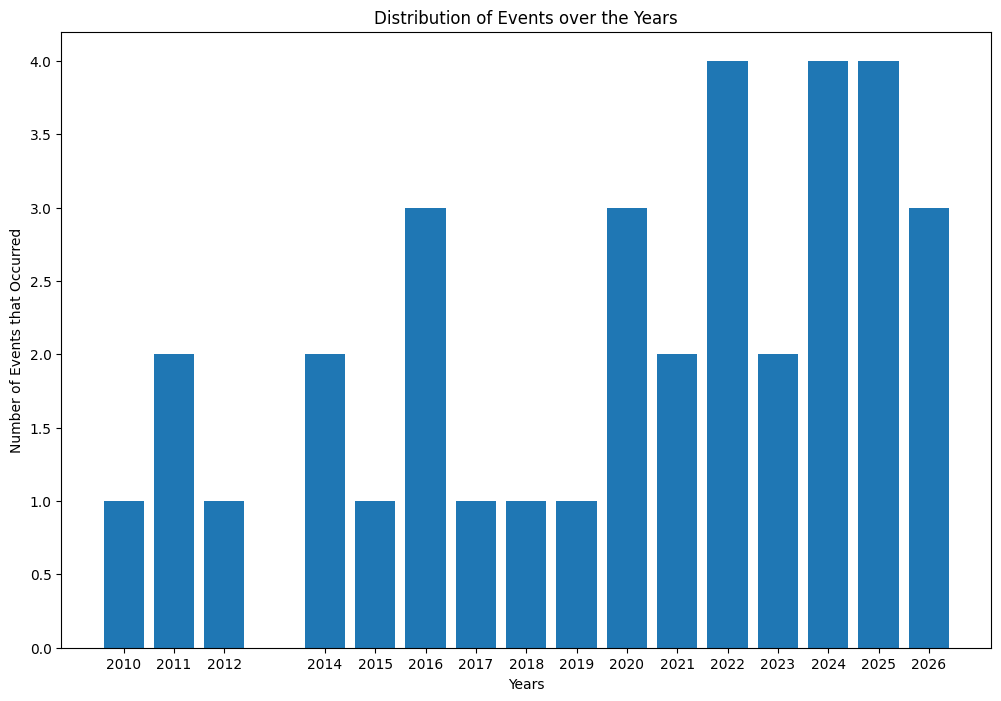

In [6]:
# Get the x and y axis of the plot
label = years.unique()
count = years.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,8))

ax.bar(label, count)
ax.set_xticks(label)

plt.title("Distribution of Events over the Years")
plt.xlabel("Years")
plt.ylabel("Number of Events that Occurred")
plt.show();

From the visualization, we can see that the most eventful year is a tie between **2022**, **2024**, and **2025** with 4 events each. With 2016, 2020, and 2026 coming in 2nd with 3 events each. It is quite concerning that 2026 already has 3 events, considering that as of creating this notebook, it is only March of 2026.

## What Event Type is the Most Common
To determine what event type is the most common, we can visualize this categorical data using a **pie chart**. This will help us understand the distribution of event types.

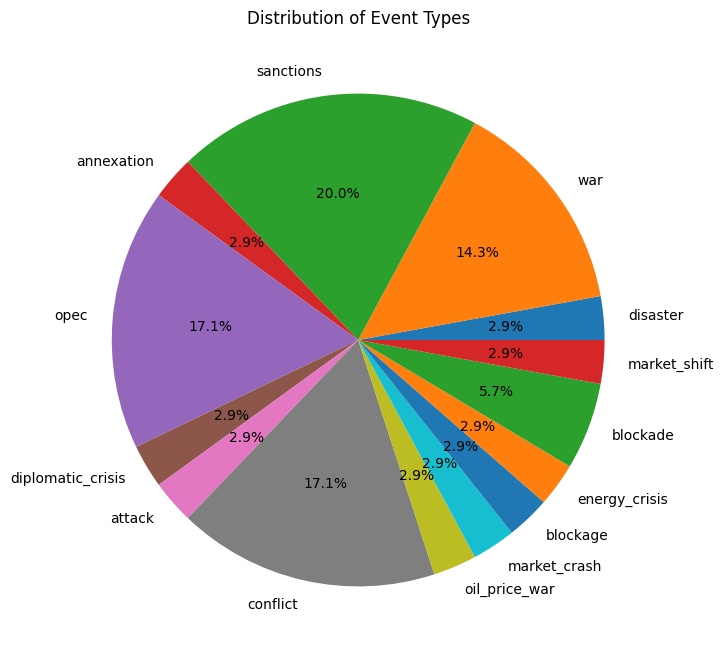

In [7]:
# Construct a dictionary to store data in the format: EVENT_TYPE:NUMBER_OF_OCCURRENCES
event_data = {}

for event in geopolitical_events['event_type'].unique():
    event_data[event] = len(geopolitical_events[geopolitical_events['event_type'] == event])

# Generating the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Setting the values and labels of the chart to the values and keys of the dictionary.
ax.pie(event_data.values(), labels=event_data.keys(), autopct='%1.1f%%')

plt.title("Distribution of Event Types")
plt.show()


Based on the visualization above, we can say that the most common event type are `sanctions` at 20%, followed by `opec` and `conflict` with 17.1% each, with `war` coming in 3rd with 14.3. These four events make up 68.5% of all events since 2010.

## What was the Most Common Event Severity Level?
To understand what severity level was the most common, we use a histogram.

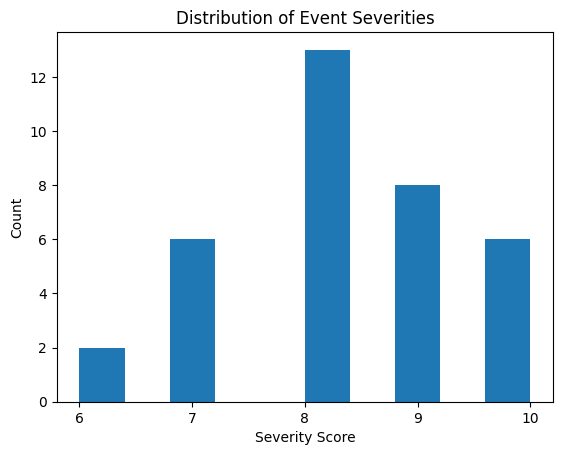

In [8]:
severities = geopolitical_events['event_severity']

fig, ax = plt.subplots()

ax.hist(severities)
ax.set_xticks(severities.unique())

plt.title("Distribution of Event Severities")
plt.xlabel("Severity Score")
plt.ylabel("Count")

plt.show();

From the visualization above, we can say that `8` is the most common severity level assigned to events, with `6` being the least common.

## Are Events Becoming More Frequent Compared to Before?
This question will help us understand whether or not the market is becoming more unstable in the present, as opposed to the past. To answer this question, we get the number of events that occurred per year and plot it with a line graph to understand the trend.

Actually, we can already answer this using the visualization we used for question #1, but using a line graph will help us better understand the trend, rather than just the number of events as a discrete value.

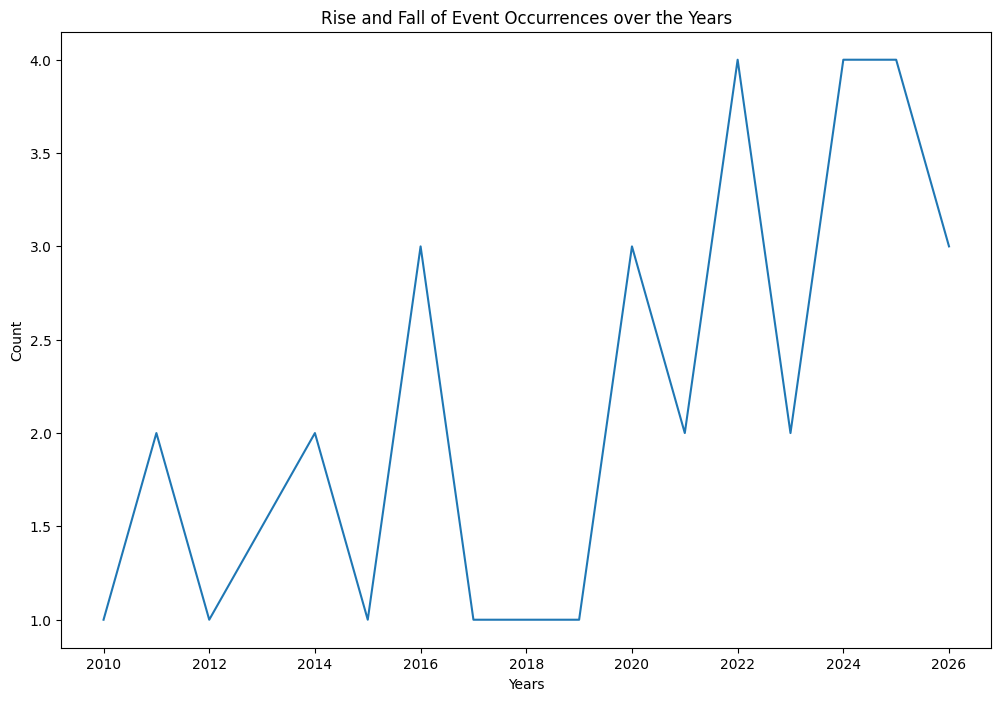

In [13]:
years = geopolitical_events.groupby(geopolitical_events['date'].dt.year).count()

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(years['date'])

plt.title("Rise and Fall of Event Occurrences over the Years")
plt.xlabel("Years")
plt.ylabel("Count")

plt.show()

From the chart above, I think we can make the conclusion that more events are happening now than before. If you compare it prior to the year 2019, some years would only have 1 event, with the highest number of events happening in 2016, with 3 events. From 2019 onwards however, the lowest number of incidents that happened in a year was 2 instead of 1 (2021 and 2023). Furthermore, we saw years with the most number of incidents by far, with 2022, 2024, and 2025 with 4 events each, which was never seen prior to 2019.

## Is the event severity of different event types going up or going down?
To do this, we must get each event type with multiple instances, and plot their values over the years. Instead of doing this for every event type, I will focus on four: `sanctions`, `opec`, and `conflict`, and `war`. The reason I want to focus on these, is because these four event types made up more than half of all the events that have occurred (68.5%). The other events occurred once only so we cannot get much data about them for this question.

We get the mean and median severity per year of each event type and plot them side by side.

In [ ]:
severity_df = geopolitical_events[['date', 'event_type', 'event_severity']]
severity_df['date'] = severity_df['date'].dt.year

# Group the values of severity_df by event_type and date, get the mean, and ungroup them
severity_means = severity_df.groupby(['event_type', 'date']).mean().reset_index()
severity_median = severity_df.groupby(['event_type', 'date']).median().reset_index()

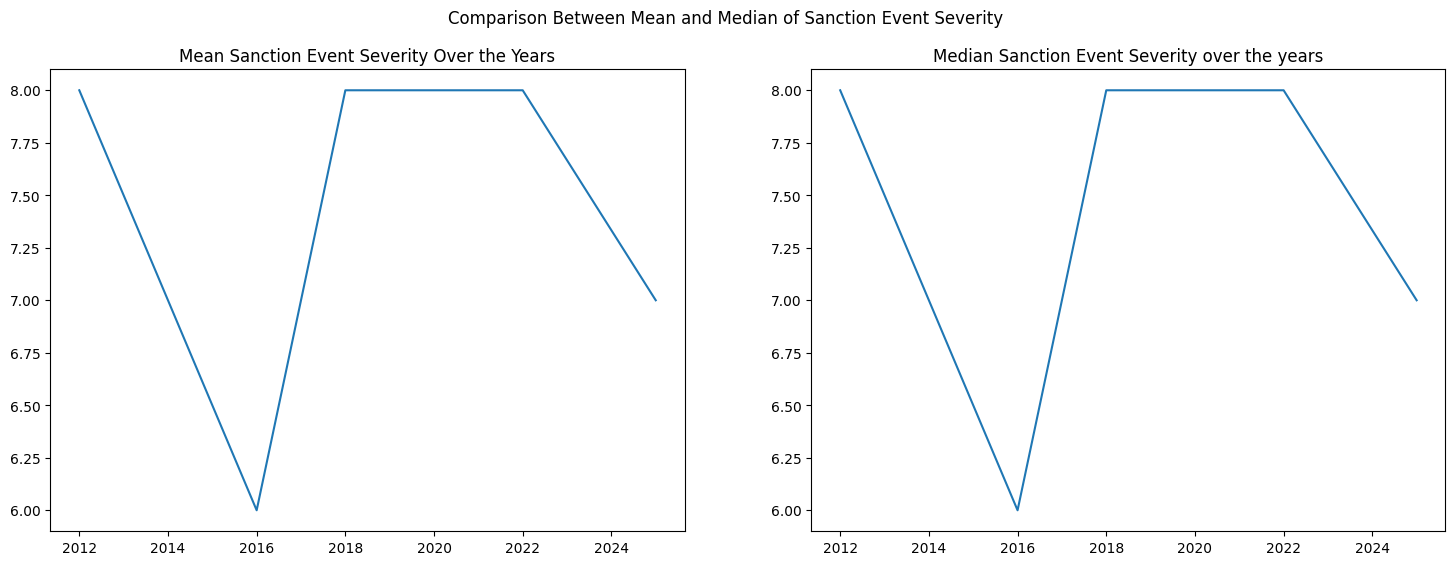

In [ ]:
# Get mean and median of sanctions over the years
mean_sanctions = severity_means[severity_means['event_type'] == 'sanctions']
median_sanctions = severity_median[severity_means['event_type'] == 'sanctions']

# Plot mean and median for sanction event severity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparison Between Mean and Median of Sanction Event Severity")

ax1.plot(mean_sanctions.date, mean_sanctions.event_severity)
ax1.set_title("Mean Sanction Event Severity Over the Years")

ax2.plot(median_sanctions.date, median_sanctions.event_severity)
ax2.set_title("Median Sanction Event Severity over the years")

plt.show();

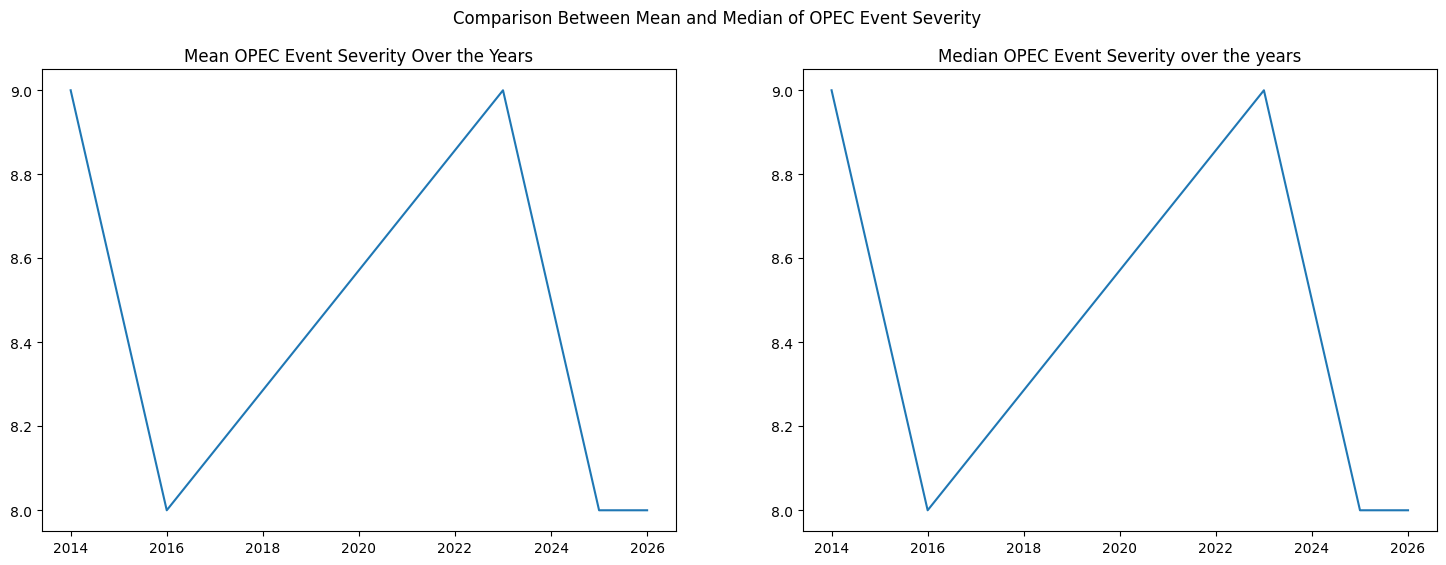

In [ ]:
# Get mean and median of opec over the years
mean_opec = severity_means[severity_means['event_type'] == 'opec']
median_opec = severity_median[severity_means['event_type'] == 'opec']

# Plot mean and median for sanction event severity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparison Between Mean and Median of OPEC Event Severity")

ax1.plot(mean_opec.date, mean_opec.event_severity)
ax1.set_title("Mean OPEC Event Severity Over the Years")

ax2.plot(median_opec.date, median_opec.event_severity)
ax2.set_title("Median OPEC Event Severity over the years")

plt.show();

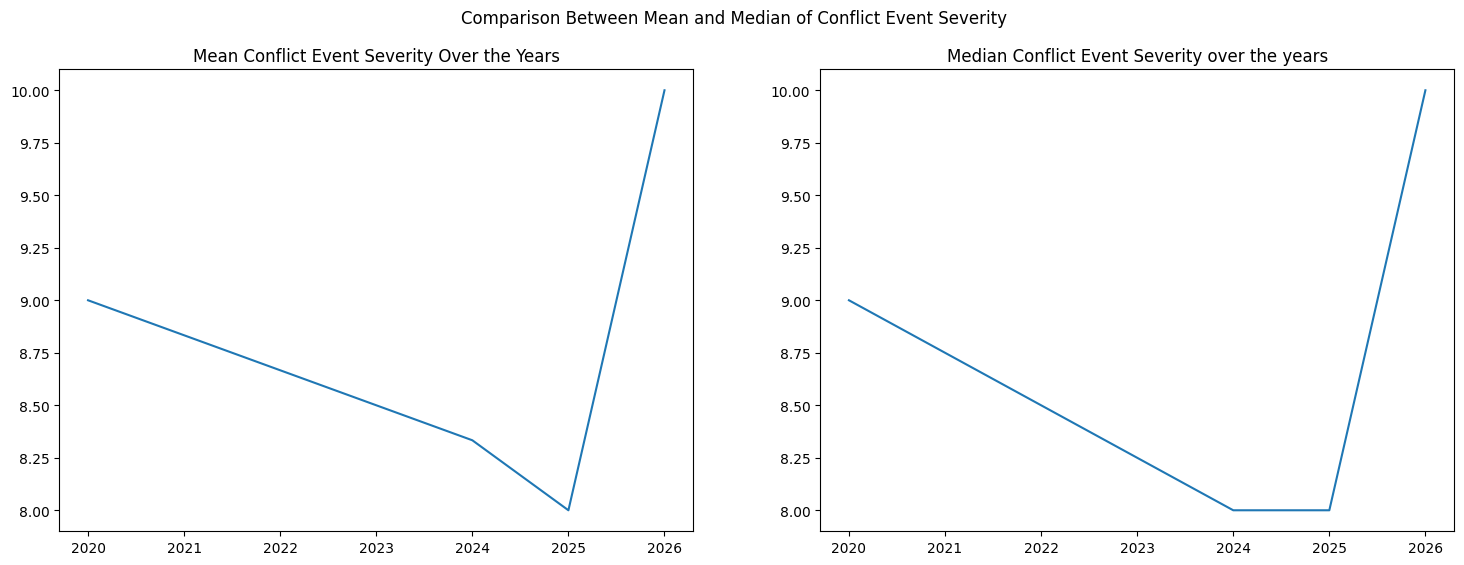

In [ ]:
# Get mean and median of conflict over the years
mean_conflict = severity_means[severity_means['event_type'] == 'conflict']
median_conflict = severity_median[severity_means['event_type'] == 'conflict']

# Plot mean and median for sanction event severity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparison Between Mean and Median of Conflict Event Severity")

ax1.plot(mean_conflict.date, mean_conflict.event_severity)
ax1.set_title("Mean Conflict Event Severity Over the Years")

ax2.plot(median_conflict.date, median_conflict.event_severity)
ax2.set_title("Median Conflict Event Severity over the years")

plt.show();

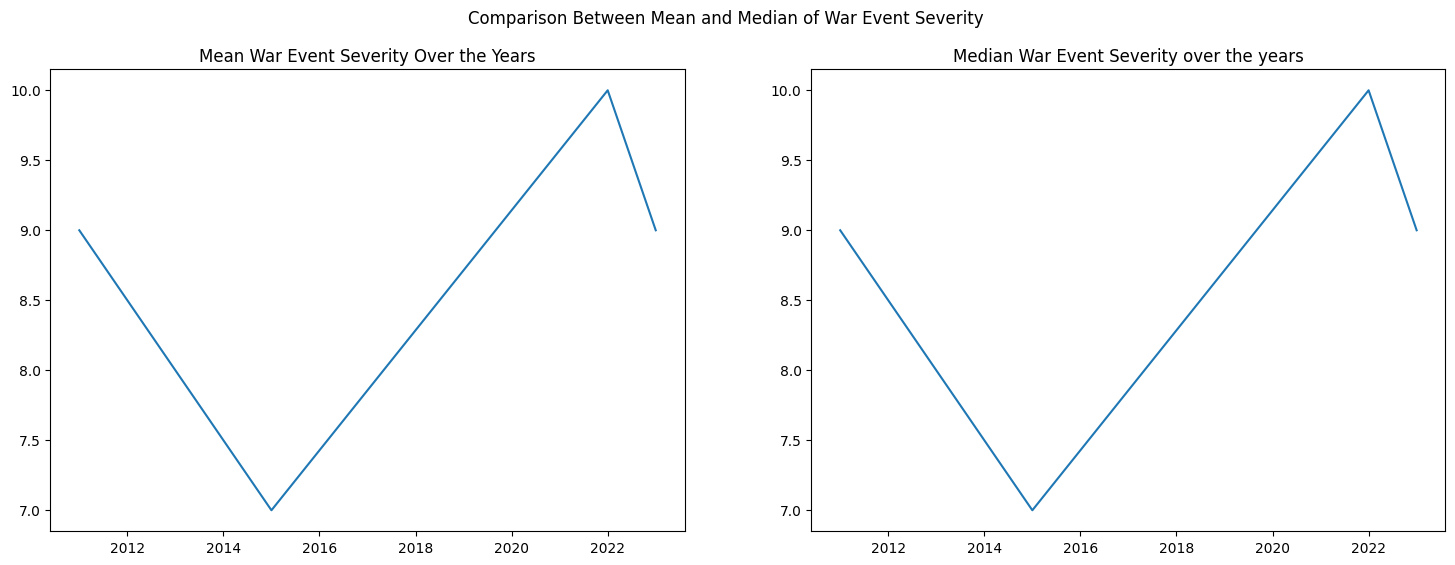

In [ ]:
# Get mean and median of war over the years
mean_war = severity_means[severity_means['event_type'] == 'war']
median_war = severity_median[severity_means['event_type'] == 'war']

# Plot mean and median for sanction event severity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparison Between Mean and Median of War Event Severity")

ax1.plot(mean_war.date, mean_war.event_severity)
ax1.set_title("Mean War Event Severity Over the Years")

ax2.plot(median_war.date, median_war.event_severity)
ax2.set_title("Median War Event Severity over the years")

plt.show();

The data above tells us that for 3 out of four events (`war`, `opec`, `sanctions`), the severity of the events is decreasing. It should be noted however that the sample size of events is very small (35 rows overall). Another observation is that the mean and median for the three event types mentioned are the same. The difference lies in the `conflict` event type, which sharply increased from an 8 to a 10.

The reasoning for this is likely related to the rising tensions between Iran, the US, and Israel. It is also for `conflict` that the mean and median differed slightly, with the mean severity for 2024 being 8.33 while the median is 8. The sharp increase to an estimated severity of 10 could mean that the current events happening could greatly affect the oil market, in a rate that was rarely seen before.

In [ ]:
geopolitical_events[geopolitical_events['event_severity'] == 10]

,date,event_type,event_description,event_severity
12,2019-09-14,attack,Saudi Aramco Abqaiq oil facility attack,10
14,2020-03-08,oil_price_war,Saudi-Russia oil price war begins,10
15,2020-04-20,market_crash,WTI crude prices turn negative,10
18,2022-02-24,war,Russia invades Ukraine,10
32,2026-02-28,conflict,US-Israel strikes on Iranian infrastructure,10
34,2026-03-09,blockade,Closure of Strait of Hormuz shipping lane,10


Returning to a previous point made earlier in this notebook, starting from the year 2019 onwards, the oil market is becoming more and more volatile, due to events occurring that affect it in a manner never seen before. With the years 2026 and 2020 having two events with an `event_severity` rating of 10. Although the column `event_severity` does not necessarily refer to oil prices going up, but rather to the rate of change, the assumption can be made based on the `event_description` that oil prices will be going up more.

## Are High Severity Events Becoming More Common Over Time?

We answered the question *"Are events becoming more frequent than before?"* but we did not dive deeper into what kind of events. Now let's find out of **high** severity events are becoming more common.

In [34]:
# Group all events by year, and get the mean and median of ALL severities.
severities_df = geopolitical_events.groupby(geopolitical_events['date'].dt.year)

mean_df = severities_df.event_severity.mean()
median_df = severities_df.event_severity.median()

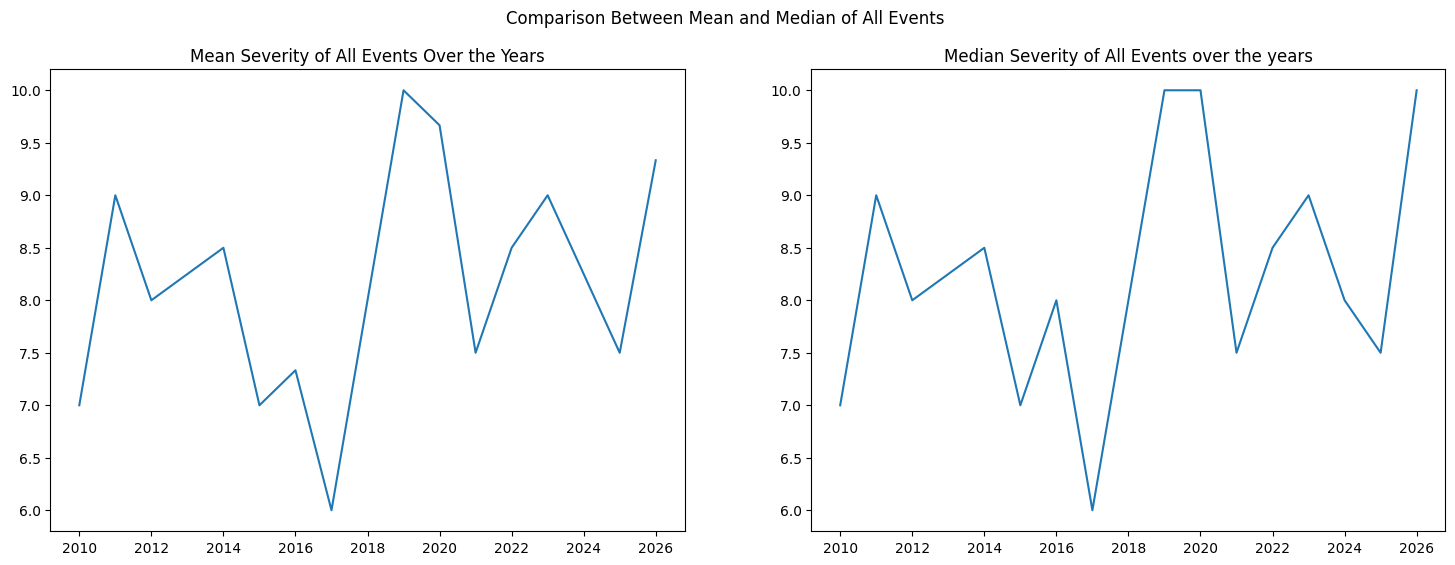

In [49]:
# Plot mean and median for sanction event severity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparison Between Mean and Median of All Events")

ax1.plot(mean_df)
ax1.set_title("Mean Severity of All Events Over the Years")

ax2.plot(median_df)
ax2.set_title("Median Severity of All Events over the years")

plt.show();

Although the resulting graphs slightly differ, they both show the trend that the overall severity of events is slowly increasing as time passes. In both cases, a peak in the year 2019 was observed, followed by a decline in event severity. With both graphs showing a gradual increase in event severity while approaching 2026.

For 2026, the mean event severity was 9.33, while the median was 10. This reflects current events as right now we are in the midst of a conflict between the US, Iran, and Israel. With the straight of Hormuz being closed by Iran, this is important because the straight is where a large percentage of the world's oil passes through. Which is why it would greatly affect the price of oil (negatively) if it were closed off.

## What Do the Severe Events Have in Common?
We have now established that the effect current events will have on the price of oil will only become greater. To better understand why, let's look at the events that affect the price of oil the most, and see if there is anything similar between them.

In [62]:
geopolitical_events[geopolitical_events['event_severity'] >= 9].sort_values('event_severity')

,date,event_type,event_description,event_severity
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
5,2014-11-27,opec,OPEC maintains production despite falling prices,9
13,2020-01-03,conflict,US kills Iranian General Qasem Soleimani,9
25,2024-04-14,conflict,Iran launches drone attack on Israel,9
23,2023-10-07,war,Israel-Hamas war begins,9
22,2023-04-02,opec,OPEC+ announces surprise production cuts,9
19,2022-03-08,sanctions,US bans Russian oil imports,9
18,2022-02-24,war,Russia invades Ukraine,10
15,2020-04-20,market_crash,WTI crude prices turn negative,10


In this case, we consider *high severity* as events having a severity score greater than 8. With this consideration, we are left with the following. If we remove `opec` related events from the table, the most common event_type is `war` and `conflict`. This tells us that **most** of the extremely severe events have occurred as the result of some conflict. With the most timely being the conflict between the US, Iran, and Israel, as well as the war between Russia and Ukraine.

## Conclusion
So what does this data all tell us? We looked at trends involving how frequent events that affect the oil market occur, if the impact these events have on the oil market are becoming more and more significant, and what the most influential events have in common.

We found out that events are becoming more frequent now than before, their impact is becoming more and more significant, and most of the most influential events involve war and conflict. If current events continue to escalate, we may observe a never before seen change in the oil market, and based on the nature of these events, it is most likely that the oil market will be more negatively affected, than positively.